# 🌾 Wheat Disease Detection — MobileNetV2 (Fast Training)
**Model:** MobileNetV2 (pretrained ImageNet)  
**Framework:** TensorFlow / Keras  
**Classes:** Brown_Rust · Healthy · Septoria · Yellow_Rust  
**Estimated Time:** ~45–60 min on free T4  
**Export:** ONNX → FastAPI

---
| Step | Description | Est. Time |
|------|-------------|----------|
| ① | Mount & Install | 2 min |
| ② | Config | — |
| ③ | Explore & Generators | 2 min |
| ④ | Build Model | 1 min |
| ⑤ | Phase 1 — Head Training | ~10 min |
| ⑥ | Phase 2 — Fine-Tuning | ~25 min |
| ⑦ | Sanity Check | 2 min |
| ⑧ | Evaluate | 3 min |
| ⑨ | Export ONNX | 2 min |
| ⑩ | Save to Drive | 2 min |

## ① Mount Drive & Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install -q tf2onnx onnx onnxruntime scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 102.9 MB/s eta 0:00:00


In [ ]:
import os, json, time, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tf2onnx
import onnxruntime as ort

tf.random.set_seed(42)
np.random.seed(42)

# Prevent OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## ② Configuration

In [ ]:
# ─────────────────────────────────────────────────────────
# ⚙️  CONFIG — update BASE_PATH if your folder name differs
# ─────────────────────────────────────────────────────────
BASE_PATH  = '/content/drive/MyDrive/Wheat-Disease-Dataset'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VAL_PATH   = os.path.join(BASE_PATH, 'val')
TEST_PATH  = os.path.join(BASE_PATH, 'test')

# Local output (fast I/O — saved to Drive at the end)
OUTPUT_DIR = '/content/wheat_mobilenet'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32        # MobileNetV2 is light — 32 is fine
SEED        = 42

# ── Epochs: early stopping will stop before max if model converges
EPOCHS_HEAD = 15        # Phase 1 — head only
EPOCHS_FINE = 30        # Phase 2 — fine-tune
LR_HEAD     = 1e-3
LR_FINE     = 1e-5

# ImageNet normalization — must match training
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# Verify paths exist
all_ok = True
for name, path in [('Train', TRAIN_PATH), ('Val', VAL_PATH), ('Test', TEST_PATH)]:
    ok = os.path.exists(path)
    print(f'  {"✅" if ok else "❌"}  {name}: {path}')
    if not ok: all_ok = False

if not all_ok:
    raise FileNotFoundError('Dataset paths not found — update BASE_PATH above')

print(f'\n✅ Config ready')
print(f'   Batch      : {BATCH_SIZE}')
print(f'   Epochs     : Head={EPOCHS_HEAD}, Fine={EPOCHS_FINE}')
print(f'   Output     : {OUTPUT_DIR}')

  ✅  Train: /content/drive/MyDrive/Wheat-Disease-Dataset/train
  ✅  Val: /content/drive/MyDrive/Wheat-Disease-Dataset/val
  ✅  Test: /content/drive/MyDrive/Wheat-Disease-Dataset/test

✅ Config ready
   Batch      : 32
   Epochs     : Head=15, Fine=30
   Output     : /content/wheat_mobilenet


## ③ Explore Dataset & Build Generators

In [ ]:
# Discover classes
CLASS_NAMES = sorted([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])
NUM_CLASSES = len(CLASS_NAMES)

# Count per split
print('📊 Dataset Summary')
print(f'{"Class":<22} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>8}')
print('─' * 58)
totals = {'Train': 0, 'Val': 0, 'Test': 0}
for cls in CLASS_NAMES:
    row = {}
    for split, path in [('Train', TRAIN_PATH), ('Val', VAL_PATH), ('Test', TEST_PATH)]:
        p = os.path.join(path, cls)
        n = len([f for f in os.listdir(p)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
               ) if os.path.exists(p) else 0
        row[split] = n
        totals[split] += n
    print(f'{cls:<22} {row["Train"]:>8} {row["Val"]:>8} {row["Test"]:>8} {sum(row.values()):>8}')

grand = sum(totals.values())
print('─' * 58)
print(f'{"TOTAL":<22} {totals["Train"]:>8} {totals["Val"]:>8} {totals["Test"]:>8} {grand:>8}')
print(f'\n  Classes : {NUM_CLASSES} → {CLASS_NAMES}')

# Save class names
with open(os.path.join(OUTPUT_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print('✅ class_names.json saved')

📊 Dataset Summary
Class                     Train      Val     Test    Total
──────────────────────────────────────────────────────────
Brown_Rust                 1005      125      126     1256
Healthy                    1270      161      160     1591
Septoria                    279       35       35      349
Yellow_Rust                1116      140      139     1395
──────────────────────────────────────────────────────────
TOTAL                      3670      461      460     4591

  Classes : 4 → ['Brown_Rust', 'Healthy', 'Septoria', 'Yellow_Rust']
✅ class_names.json saved


In [ ]:
# ── Preprocessing function
def imagenet_preprocess(img):
    img = img.astype(np.float32) / 255.0
    return (img - MEAN) / STD

# ── Augmentation (training only)
train_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=[0.82, 1.18],
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess
)

def make_generators():
    tg = train_datagen.flow_from_directory(
        TRAIN_PATH, target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=SEED
    )
    vg = val_datagen.flow_from_directory(
        VAL_PATH, target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )
    eg = val_datagen.flow_from_directory(
        TEST_PATH, target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )
    return tg, vg, eg

train_gen, val_gen, test_gen = make_generators()

# Sync class names to generator ordering (alphabetical)
CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f'\n✅ Generators ready')
print(f'   Classes : {CLASS_NAMES}')
print(f'   Train   : {train_gen.samples} images | {train_gen.samples//BATCH_SIZE} batches/epoch')
print(f'   Val     : {val_gen.samples} images')
print(f'   Test    : {test_gen.samples} images')

# ── Compute class weights (fixes imbalanced data bias)
cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
CLASS_WEIGHTS = dict(enumerate(cw_values))
print(f'\n  Class weights (for imbalance correction):')
for i, cls in enumerate(CLASS_NAMES):
    print(f'    {cls:<22} → {CLASS_WEIGHTS[i]:.4f}')

Found 3670 images belonging to 4 classes.
Found 461 images belonging to 4 classes.
Found 460 images belonging to 4 classes.

✅ Generators ready
   Classes : ['Brown_Rust', 'Healthy', 'Septoria', 'Yellow_Rust']
   Train   : 3670 images | 114 batches/epoch
   Val     : 461 images
   Test    : 460 images

  Class weights (for imbalance correction):
    Brown_Rust             → 0.9129
    Healthy                → 0.7224
    Septoria               → 3.2885
    Yellow_Rust            → 0.8221


## ④ Build MobileNetV2 Model

In [ ]:
def build_mobilenetv2(num_classes, input_shape=(224, 224, 3), dropout=0.35):
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    inputs  = layers.Input(shape=input_shape, name='input_image')
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.BatchNormalization(name='bn_1')(x)
    x       = layers.Dropout(dropout, name='drop_1')(x)
    x       = layers.Dense(
                  256, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4),
                  name='dense_256'
              )(x)
    x       = layers.BatchNormalization(name='bn_2')(x)
    x       = layers.Dropout(dropout / 2, name='drop_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='MobileNetV2_WheatDisease')
    return model, base

model, base_model = build_mobilenetv2(NUM_CLASSES)

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  (head only — backbone frozen)')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 2,593,092
Trainable params : 332,036  (head only — backbone frozen)


Model: "MobileNetV2_WheatDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,092 (9.89 MB)

 Trainable params: 332,036 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

## ⑤ Phase 1 — Train Head Only
> Backbone frozen. Only the classification head learns. ~10 min.

In [ ]:
CKPT_HEAD = os.path.join(OUTPUT_DIR, 'mobilenet_head_best.keras')

cb_head = [
    callbacks.ModelCheckpoint(
        CKPT_HEAD, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-8, verbose=1
    )
]

model.compile(
    optimizer=Adam(LR_HEAD),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print('🚀 Phase 1 — Training head (backbone frozen)...')
t0 = time.time()

hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb_head,
    verbose=1
)

p1_time = (time.time() - t0) / 60
p1_best = max(hist1.history['val_accuracy'])
print(f'\n✅ Phase 1 done')
print(f'   Best val_accuracy : {p1_best:.4f} ({p1_best*100:.2f}%)')
print(f'   Time              : {p1_time:.1f} min')

🚀 Phase 1 — Training head (backbone frozen)...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7066 - loss: 0.9697 
Epoch 1: val_accuracy improved from None to 0.85466, saving model to /content/wheat_mobilenet/mobilenet_head_best.keras

Epoch 1: finished saving model to /content/wheat_mobilenet/mobilenet_head_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 1399s 12s/step - accuracy: 0.7886 - loss: 0.8142 - val_accuracy: 0.8547 - val_loss: 0.5887 - learning_rate: 0.0010
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.8588 - loss: 0.6339
Epoch 2: val_accuracy improved from 0.85466 to 0.87202, saving model to /content/wheat_mobilenet/mobilenet_head_best.keras

Epoch 2: finished saving model to /content/wheat_mobilenet/mobilenet_head_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 105s 913ms/step - accuracy: 0.8531 - loss: 0.6300 - val_accuracy: 0.8720 - val_loss: 0.5274 - learning_rate: 0.0010
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.8683 -

## ⑥ Phase 2 — Fine-Tune Top Backbone Layers
> Unfreeze top 30 layers. Lower LR. ~25 min.

In [ ]:
# Unfreeze top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

frozen    = sum(1 for l in base_model.layers if not l.trainable)
unfrozen  = sum(1 for l in base_model.layers if l.trainable)
print(f'Backbone layers  : {len(base_model.layers)} total')
print(f'  Frozen         : {frozen}')
print(f'  Unfrozen (top) : {unfrozen}')

CKPT_FINE = os.path.join(OUTPUT_DIR, 'mobilenet_fine_best.keras')

cb_fine = [
    callbacks.ModelCheckpoint(
        CKPT_FINE, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=5, min_lr=1e-8, verbose=1
    )
]

model.compile(
    optimizer=Adam(LR_FINE),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print('\n🚀 Phase 2 — Fine-tuning top backbone layers...')
t0 = time.time()

hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb_fine,
    verbose=1
)

p2_time = (time.time() - t0) / 60
p2_best = max(hist2.history['val_accuracy'])
print(f'\n✅ Phase 2 done')
print(f'   Best val_accuracy : {p2_best:.4f} ({p2_best*100:.2f}%)')
print(f'   Time              : {p2_time:.1f} min')
print(f'   Total time        : {(p1_time + p2_time):.1f} min')

Backbone layers  : 154 total
  Frozen         : 124
  Unfrozen (top) : 30

🚀 Phase 2 — Fine-tuning top backbone layers...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.8755 - loss: 0.5853
Epoch 1: val_accuracy improved from None to 0.91106, saving model to /content/wheat_mobilenet/mobilenet_fine_best.keras

Epoch 1: finished saving model to /content/wheat_mobilenet/mobilenet_fine_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8757 - loss: 0.5788 - val_accuracy: 0.9111 - val_loss: 0.5500 - learning_rate: 1.0000e-05
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.8824 - loss: 0.5522
Epoch 2: val_accuracy did not improve from 0.91106
115/115 ━━━━━━━━━━━━━━━━━━━━ 103s 895ms/step - accuracy: 0.8907 - loss: 0.5233 - val_accuracy: 0.9046 - val_loss: 0.5943 - learning_rate: 1.0000e-05
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.8974 - loss: 0.5174
Epoch 3: val_accuracy did not improve from 0.91106
115/115 ━━━

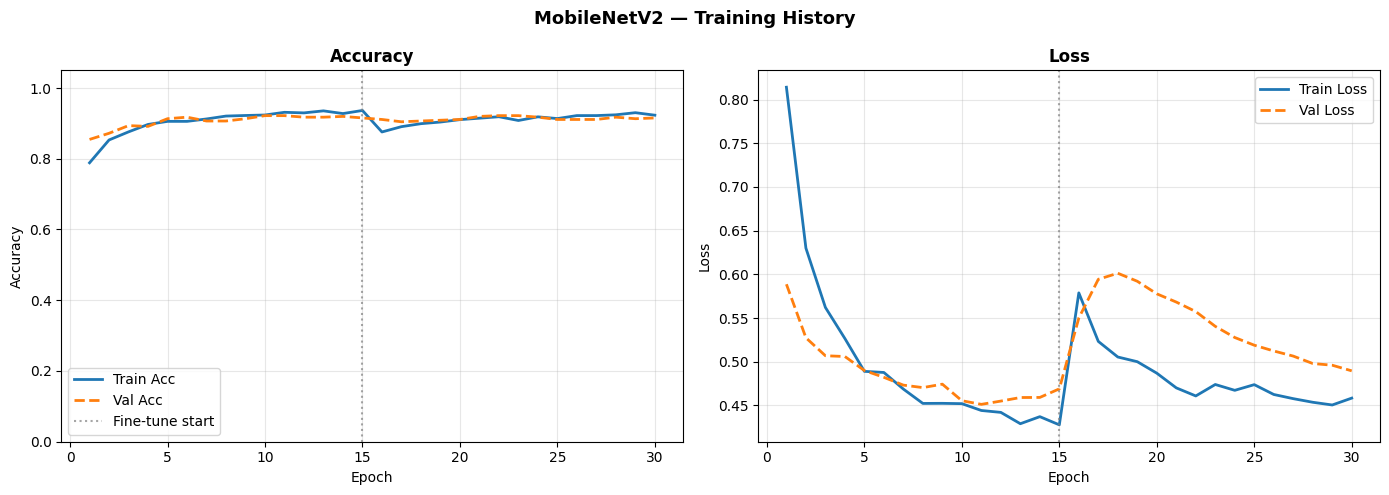

Overall best val_accuracy: 92.19%


In [15]:
# ── Merge histories & plot curves
p1_end = len(hist1.history['accuracy'])
acc    = hist1.history['accuracy']    + hist2.history['accuracy']
val_ac = hist1.history['val_accuracy']+ hist2.history['val_accuracy']
loss   = hist1.history['loss']        + hist2.history['loss']
val_ls = hist1.history['val_loss']    + hist2.history['val_loss']
ep     = range(1, len(acc)+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, acc,    lw=2, label='Train Acc')
axes[0].plot(ep, val_ac, lw=2, linestyle='--', label='Val Acc')
axes[0].axvline(p1_end, color='gray', linestyle=':', alpha=0.7, label='Fine-tune start')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1.05])
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, loss,   lw=2, label='Train Loss')
axes[1].plot(ep, val_ls, lw=2, linestyle='--', label='Val Loss')
axes[1].axvline(p1_end, color='gray', linestyle=':', alpha=0.7)
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('MobileNetV2 — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print(f'Overall best val_accuracy: {max(val_ac)*100:.2f}%')

## ⑦ Sanity Check — Must Pass Before Export
> **DO NOT skip this cell.** If it fails, do not export ONNX.

In [16]:
# Load best fine-tuned checkpoint
best_model = tf.keras.models.load_model(CKPT_FINE)
print(f'✅ Loaded best model from: {CKPT_FINE}\n')

train_gen, val_gen, test_gen = make_generators()
test_gen.reset()

preds  = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

unique_preds = np.unique(y_pred)
missing      = [CLASS_NAMES[i] for i in range(NUM_CLASSES) if i not in unique_preds]

print('\n🔬 Sanity Check Results:')
print(f'   Classes expected  : {CLASS_NAMES}')
print(f'   Classes predicted : {[CLASS_NAMES[i] for i in unique_preds]}')

if missing:
    print(f'\n❌ FAIL — Model never predicts: {missing}')
    print('   DO NOT export ONNX. The model did not converge properly.')
    print('   → Re-run Phase 1 and Phase 2 cells with more epochs.')
    SAFE_TO_EXPORT = False
else:
    print('\n✅ PASS — All classes predicted')
    print('\n   Per-class accuracy:')
    all_good = True
    for i, cls in enumerate(CLASS_NAMES):
        mask     = y_true == i
        acc      = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0
        avg_conf = preds[mask][:, i].mean()   if mask.sum() > 0 else 0
        status   = '✅' if acc >= 0.65 else '⚠️ '
        if acc < 0.65: all_good = False
        print(f'   {status} {cls:<22} acc={acc*100:.1f}%  avg_conf={avg_conf:.3f}')

    SAFE_TO_EXPORT = True
    if not all_good:
        print('\n⚠️  Some classes below 65% — model exported but may underperform on those classes.')
        print('   Consider retraining with more epochs for weak classes.')
    else:
        print('\n🎉 All classes above 65% — model is healthy!')

✅ Loaded best model from: /content/wheat_mobilenet/mobilenet_fine_best.keras

Found 3670 images belonging to 4 classes.
Found 461 images belonging to 4 classes.
Found 460 images belonging to 4 classes.
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 815ms/step

🔬 Sanity Check Results:
   Classes expected  : ['Brown_Rust', 'Healthy', 'Septoria', 'Yellow_Rust']
   Classes predicted : ['Brown_Rust', 'Healthy', 'Septoria', 'Yellow_Rust']

✅ PASS — All classes predicted

   Per-class accuracy:
   ✅ Brown_Rust             acc=88.9%  avg_conf=0.844
   ✅ Healthy                acc=98.8%  avg_conf=0.976
   ✅ Septoria               acc=77.1%  avg_conf=0.765
   ✅ Yellow_Rust            acc=95.0%  avg_conf=0.902

🎉 All classes above 65% — model is healthy!


## ⑧ Evaluate — Confusion Matrix & Report

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 742ms/step - accuracy: 0.9326 - loss: 0.5423

📊 Test Accuracy : 93.26%
   Test Loss     : 0.5423

📋 Classification Report:
              precision    recall  f1-score   support

  Brown_Rust       0.97      0.89      0.93       126
     Healthy       0.94      0.99      0.96       160
    Septoria       0.82      0.77      0.79        35
 Yellow_Rust       0.92      0.95      0.93       139

    accuracy                           0.93       460
   macro avg       0.91      0.90      0.90       460
weighted avg       0.93      0.93      0.93       460



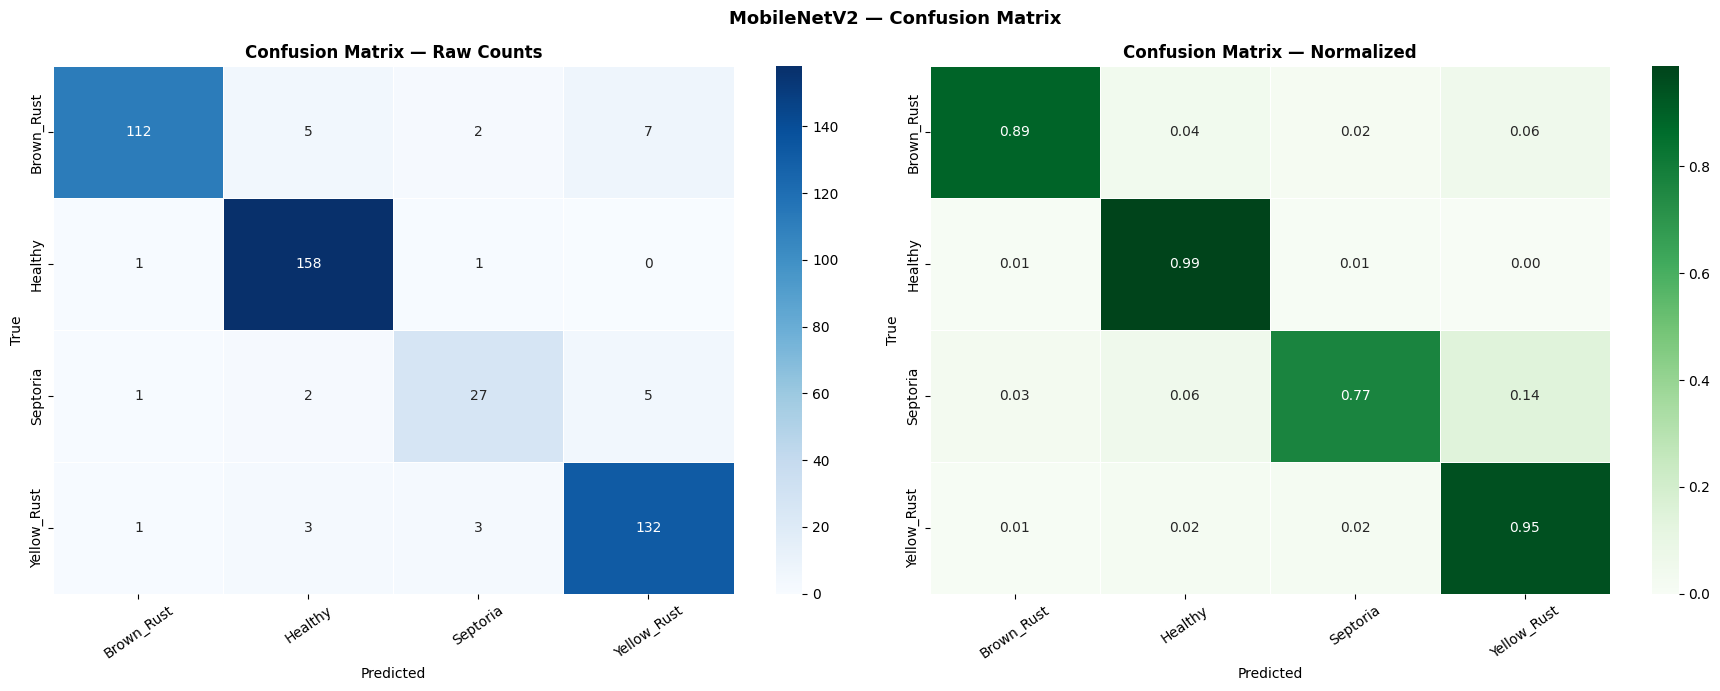

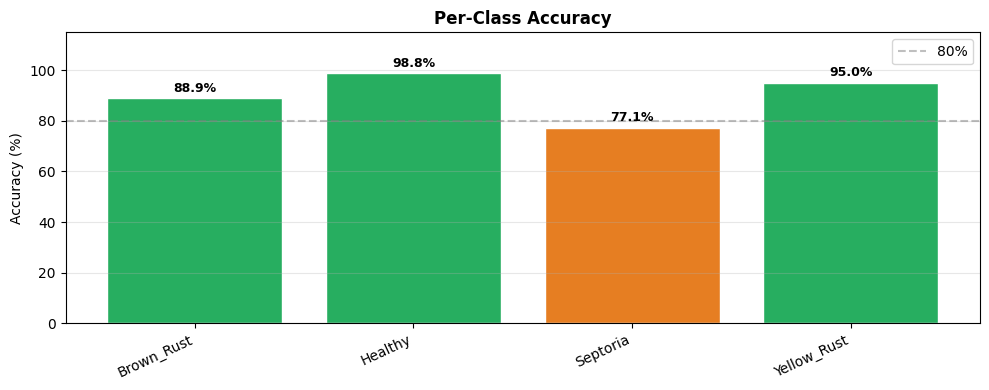

In [17]:
if not SAFE_TO_EXPORT:
    print('⛔ Skipping evaluation — model failed sanity check. Retrain first.')
else:
    test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
    print(f'\n📊 Test Accuracy : {test_acc*100:.2f}%')
    print(f'   Test Loss     : {test_loss:.4f}')

    report_str = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, zero_division=0
    )
    print('\n📋 Classification Report:')
    print(report_str)

    with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
        f.write(f'Test Accuracy : {test_acc*100:.2f}%\n')
        f.write(f'Test Loss     : {test_loss:.4f}\n\n')
        f.write(report_str)

    # Confusion matrix
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', ax=axes[0], linewidths=0.5)
    axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    axes[0].tick_params(axis='x', rotation=35)

    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Greens', ax=axes[1], linewidths=0.5)
    axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    axes[1].tick_params(axis='x', rotation=35)

    plt.suptitle('MobileNetV2 — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
    plt.show()

    # Per-class accuracy bar
    per_cls = cm_norm.diagonal()
    colors  = ['#27ae60' if v >= 0.85 else '#e67e22' if v >= 0.65 else '#e74c3c'
               for v in per_cls]
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(CLASS_NAMES, per_cls*100, color=colors, edgecolor='white')
    ax.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80%')
    ax.set_ylim([0, 115]); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy', fontweight='bold')
    plt.xticks(rotation=25, ha='right'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, per_cls):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1.5,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='600')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_acc.png'), dpi=150)
    plt.show()

## ⑨ Export to ONNX

In [18]:
if not SAFE_TO_EXPORT:
    print('⛔ Skipping ONNX export — model failed sanity check.')
else:
    import tf2onnx

    ONNX_PATH = os.path.join(OUTPUT_DIR, 'wheat_disease_model.onnx')

    input_sig = [tf.TensorSpec(
        shape=(None, 224, 224, 3),
        dtype=tf.float32,
        name='input_image'
    )]

    print('⏳ Exporting to ONNX (opset 13)...')
    proto, _ = tf2onnx.convert.from_keras(
        best_model,
        input_signature=input_sig,
        opset=13,
        output_path=ONNX_PATH
    )

    size_mb = os.path.getsize(ONNX_PATH) / (1024**2)
    print(f'\n✅ ONNX saved  : {ONNX_PATH}')
    print(f'   Size        : {size_mb:.1f} MB')

    # Quick ONNX verification
    sess     = ort.InferenceSession(ONNX_PATH)
    in_name  = sess.get_inputs()[0].name
    out_name = sess.get_outputs()[0].name

    # Verify all 4 classes with 20 random noise inputs
    np.random.seed(0)
    preds_noise = []
    for _ in range(20):
        r   = np.random.rand(1,224,224,3).astype(np.float32)
        r   = (r - MEAN) / STD
        out = sess.run([out_name], {in_name: r.astype(np.float32)})[0][0]
        preds_noise.append(int(np.argmax(out)))

    unique_noise = set(preds_noise)
    print(f'\n🔬 ONNX noise test — unique classes predicted: {[CLASS_NAMES[i] for i in unique_noise]}')

    if len(unique_noise) >= 3:
        print('✅ ONNX model is NOT degenerate — predicting varied classes')
    else:
        print('⚠️  Model may still be biased — check test results above')

    # Test on one real image per class
    print('\n🧪 ONNX Spot-Check (1 image per class from test set):')
    print(f'  {"True":<22} {"Predicted":<22} {"Conf":>6}  Status')
    print('  ' + '-'*58)
    for cls in CLASS_NAMES:
        p = os.path.join(TEST_PATH, cls)
        if not os.path.exists(p): continue
        imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if not imgs: continue
        img  = load_img(os.path.join(p, imgs[0]), target_size=(224,224))
        arr  = img_to_array(img).astype(np.float32) / 255.0
        arr  = (arr - MEAN) / STD
        out  = sess.run([out_name], {in_name: arr[np.newaxis].astype(np.float32)})[0][0]
        pred = CLASS_NAMES[int(np.argmax(out))]
        conf = float(np.max(out))
        ok   = '✅' if pred == cls else '❌'
        print(f'  {cls:<22} {pred:<22} {conf:>5.1%}  {ok}')

⏳ Exporting to ONNX (opset 13)...

✅ ONNX saved  : /content/wheat_mobilenet/wheat_disease_model.onnx
   Size        : 9.8 MB

🔬 ONNX noise test — unique classes predicted: ['Healthy']
⚠️  Model may still be biased — check test results above

🧪 ONNX Spot-Check (1 image per class from test set):
  True                   Predicted                Conf  Status
  ----------------------------------------------------------
  Brown_Rust             Brown_Rust             97.0%  ✅
  Healthy                Healthy                97.3%  ✅
  Septoria               Septoria               94.3%  ✅
  Yellow_Rust            Septoria               87.7%  ❌


## ⑩ Save Everything to Google Drive

In [19]:
import shutil

DRIVE_OUT = '/content/drive/MyDrive/wheat_mobilenet_final'
os.makedirs(DRIVE_OUT, exist_ok=True)

print(f'📤 Copying files to Drive: {DRIVE_OUT}\n')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    src  = os.path.join(OUTPUT_DIR, fname)
    dst  = os.path.join(DRIVE_OUT, fname)
    size = os.path.getsize(src) / (1024**2)
    shutil.copy2(src, dst)
    tag  = '  ← DEPLOY THIS' if fname.endswith('.onnx') else ''
    print(f'  ✅ {fname:<45} {size:>6.1f} MB{tag}')

print(f'\n🎉 All files saved to Google Drive!')
print(f'\n   For FastAPI deployment, download:')
print(f'   1. wheat_disease_model.onnx')
print(f'   2. class_names.json')

📤 Copying files to Drive: /content/drive/MyDrive/wheat_mobilenet_final

  ✅ class_names.json                                 0.0 MB
  ✅ classification_report.txt                        0.0 MB
  ✅ confusion_matrix.png                             0.1 MB
  ✅ mobilenet_fine_best.keras                       24.7 MB
  ✅ mobilenet_head_best.keras                       13.0 MB
  ✅ per_class_acc.png                                0.0 MB
  ✅ training_curves.png                              0.1 MB
  ✅ wheat_disease_model.onnx                         9.8 MB  ← DEPLOY THIS

🎉 All files saved to Google Drive!

   For FastAPI deployment, download:
   1. wheat_disease_model.onnx
   2. class_names.json


---
## 📌 Notes

### FastAPI preprocessing (copy exactly)
```python
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    img = img.resize((224, 224), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - MEAN) / STD
    return np.expand_dims(arr, 0).astype(np.float32)
```

### If Colab disconnects mid-training
Best checkpoint is saved to `/content/wheat_mobilenet/mobilenet_fine_best.keras` every epoch.  
To resume fine-tuning after reconnect:
```python
model = tf.keras.models.load_model('/content/wheat_mobilenet/mobilenet_fine_best.keras')
# Then re-run Phase 2 cell — it will continue improving from the checkpoint
```

### Class names order
```json
["Brown_Rust", "Healthy", "Septoria", "Yellow_Rust"]
```
Index 0=Brown_Rust, 1=Healthy, 2=Septoria, 3=Yellow_Rust